In [1]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from atmo3.ice_emission import complex_permittivity_ice, complex_permittivity_liquid_water_hybrid_K
from matplotlib import pyplot as plt

<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:80: SyntaxWarning: invalid escape sequence '\e'
<>:79: SyntaxWarning: invalid escape sequence '\e'
<>:80: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_1251392/3662325330.py:79: SyntaxWarning: invalid escape sequence '\e'
  ax1.set_ylabel("$\epsilon'$", fontsize=16)
/tmp/ipykernel_1251392/3662325330.py:80: SyntaxWarning: invalid escape sequence '\e'
  ax2.set_ylabel("$\epsilon''$", fontsize=16)


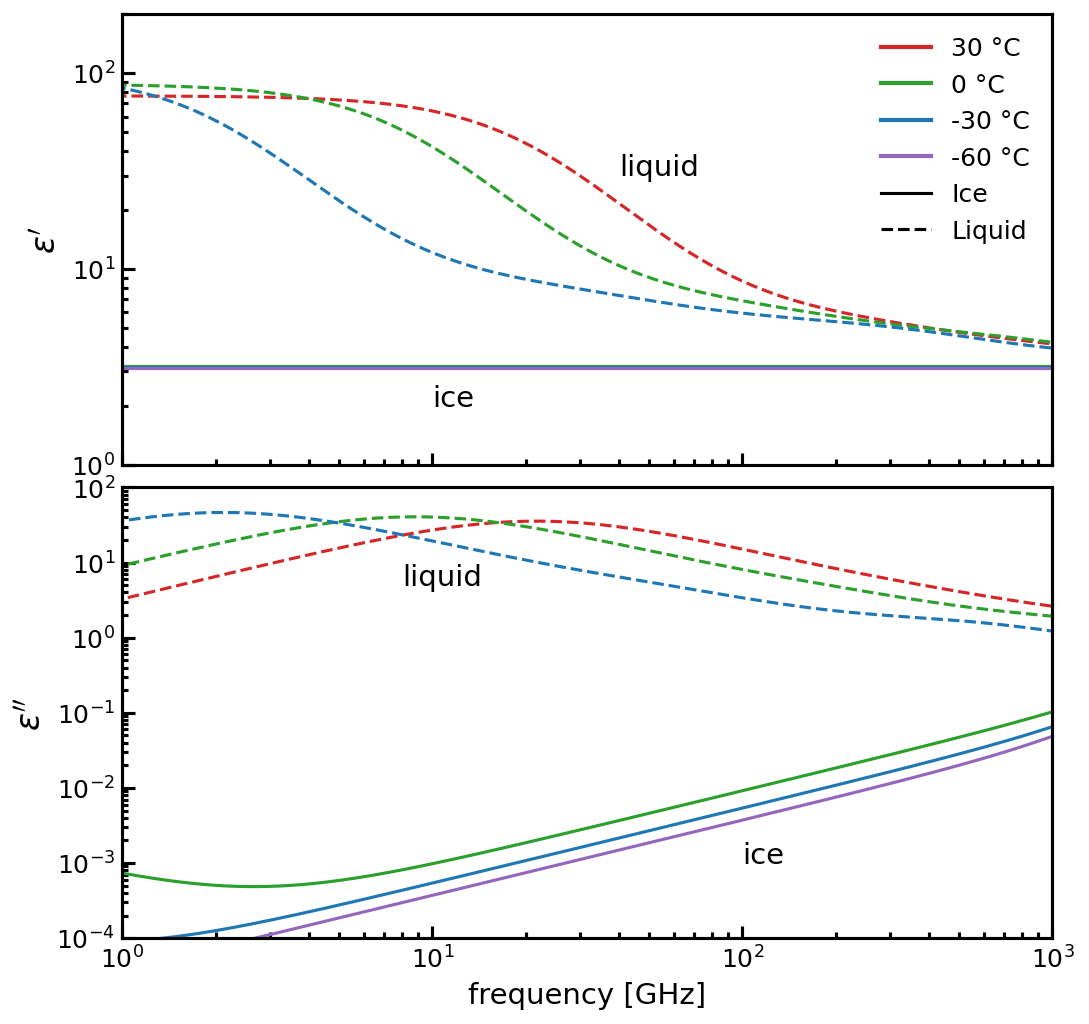

In [10]:
import jax
jax.config.update('jax_platform_name', 'cpu')
jax.config.update('jax_platforms', 'cpu')
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from atmo3.ice_emission import complex_permittivity_ice, complex_permittivity_liquid_water_hybrid_K
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ==========================================
# --- 1. User Parameters ---
# ==========================================
# Frequency grid setup (in GHz)
FREQ_MIN = 0.1
FREQ_MAX = 1000.0
FREQ_POINTS = 500

freqs_ghz = jnp.logspace(jnp.log10(FREQ_MIN), jnp.log10(FREQ_MAX), FREQ_POINTS)

# Define the temperatures for each state (in Celsius)
T_ice_C = [0, -30, -60]
T_liq_C = [30, 0, -30]

# Define a unified color palette for the 4 unique temperatures
color_map = {
    30: 'tab:red',
    0: 'tab:green',
    -30: 'tab:blue',
    -60: 'tab:purple'
}

# ==========================================
# --- 2. Setup Plot ---
# ==========================================
# Create a figure with 2 subplots sharing the X-axis
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(8, 8), dpi=150)

# ==========================================
# --- 3. Compute and Plot Data ---
# ==========================================

# --- Ice (Solid Lines) ---
for T_C in T_ice_C:
    T_K = T_C + 273.15
    eps_ice = complex_permittivity_ice(T_K, freqs_ghz)
    
    # Plot Real part (Top)
    ax1.plot(freqs_ghz, eps_ice.real, color=color_map[T_C], linestyle='-', lw=1.5)
    # Plot Imaginary part (Bottom)
    ax2.plot(freqs_ghz, eps_ice.imag, color=color_map[T_C], linestyle='-', lw=1.5)

# --- Liquid Water (Dashed Lines) ---
for T_C in T_liq_C:
    T_K = T_C + 273.15
    eps_liq = complex_permittivity_liquid_water_hybrid_K(T_K, freqs_ghz)
    
    # Plot Real part (Top)
    ax1.plot(freqs_ghz, eps_liq.real, color=color_map[T_C], linestyle='--', lw=1.5)
    # Plot Imaginary part (Bottom)
    ax2.plot(freqs_ghz, eps_liq.imag, color=color_map[T_C], linestyle='--', lw=1.5)


# ==========================================
# --- 4. Formatting and Legend ---
# ==========================================

# Configure axes to be log-log
for ax in (ax1, ax2):
    ax.set_xscale('log')
    ax.set_yscale('log')
    # Thicken borders to match the reference image style
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(which='both', width=1.5, direction='in', labelsize=12)
    ax.tick_params(which='major', length=6)
    ax.tick_params(which='minor', length=3)

# Axis labels
ax1.set_ylabel("$\epsilon'$", fontsize=16)
ax2.set_ylabel("$\epsilon''$", fontsize=16)
ax2.set_xlabel("frequency [GHz]", fontsize=14)

# Set common X limits
ax1.set_xlim(FREQ_MIN, FREQ_MAX)

# --- Construct Custom Legend ---
all_temps = [30, 0, -30, -60]

# 1. Temperature handles
temp_handles = [
    Line2D([0], [0], color=color_map[T], lw=2, label=f'{T} °C') 
    for T in all_temps
]

# 2. Add a blank spacer handle for clean separation
spacer = Line2D([0], [0], color='none', label=' ')

# 3. State handles (black to emphasize it just denotes the style)
state_handles = [
    Line2D([0], [0], color='black', linestyle='-', lw=1.5, label='Ice'),
    Line2D([0], [0], color='black', linestyle='--', lw=1.5, label='Liquid')
]

# Combine them all into the top subplot
ax1.legend(handles=temp_handles + state_handles, 
           loc='upper right', frameon=False, fontsize=12)

ax1.set_ylim(1e0, 2e2)
ax2.set_ylim(1e-4, 1e2)

ax1.set_xlim(1e0, 1e3)
ax2.set_xlim(1e0, 1e3)

# Text annotations directly on the plots (optional, to mimic the image exactly)
ax1.text(10, 2, 'ice', fontsize=14)
ax1.text(40, 30, 'liquid', fontsize=14)

ax2.text(100, 1e-3, 'ice', fontsize=14)
ax2.text(8, 5, 'liquid', fontsize=14)

# Remove gap between subplots
plt.subplots_adjust(hspace=0.05)

plt.show()